# Model Training & Evaluation

6 models × random/temporal splits

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from logistics_delay.data.loader import load_processed
from logistics_delay.features.engineering import get_feature_lists
from logistics_delay.models.train import random_split, temporal_split
from logistics_delay.models.evaluate import evaluate, get_model, ALL_MODELS, _prepare_xgb_input
from logistics_delay.utils.paths import FIGURES_MODELS, ensure_output_dirs
import warnings
warnings.filterwarnings('ignore', message='findfont: Font family')
warnings.filterwarnings('ignore')

# ── Publication style ──────────────────────────
PALETTE = {
    "blue_main": "#0F4D92", "blue_secondary": "#3775BA",
    "green_1": "#DDF3DE", "green_2": "#AADCA9", "green_3": "#8BCF8B",
    "red_1": "#F6CFCB", "red_2": "#E9A6A1", "red_strong": "#B64342",
    "neutral": "#CFCECE", "highlight": "#FFD700",
    "teal": "#42949E", "violet": "#9A4D8E",
}

plt.rcParams.update({
    "font.family": ["Arial", "SimHei", "DejaVu Sans", "sans-serif"],
    "font.size": 15,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.linewidth": 2.5,
    "legend.frameon": False,
    "svg.fonttype": "none",
})
plt.rcParams['axes.unicode_minus'] = False
ensure_output_dirs()
print("[OK] Imports complete")

[OK] Imports complete


In [2]:
df = load_processed()
FEATURES_ENC, FEATURES_XGB, XGB_CAT_COLS = get_feature_lists()
X_enc = df[FEATURES_ENC]
X_xgb = df[FEATURES_XGB]
y = df['Answer']
print(f'Data shape: {df.shape}')
print(f'Delay rate: {y.mean()*100:.1f}%')

[loader] Preprocessed data loaded: (6854, 54)
[loader] Delay rate: 63.19%
Data shape: (6854, 54)
Delay rate: 63.2%


In [3]:
# ── Random split ──
X_train_r, X_test_r, y_train_r, y_test_r, spw_r = random_split(df, "enc")
X_train_r_xgb = X_xgb.loc[X_train_r.index]
X_test_r_xgb = X_xgb.loc[X_test_r.index]

[train] Random split: train 5483 / test 1371
[train] scale_pos_weight = 0.5824


In [4]:
# ── Temporal split ──
X_train_t, X_test_t, y_train_t, y_test_t, spw_t, cutoff = temporal_split(df, "enc")
X_train_t_xgb = FEATURES_XGB and df.sort_values('trip_start_date').reset_index(drop=True).loc[:int(len(df)*0.8)-1, FEATURES_XGB].reset_index(drop=True)
X_test_t_xgb = FEATURES_XGB and df.sort_values('trip_start_date').reset_index(drop=True).loc[int(len(df)*0.8):, FEATURES_XGB].reset_index(drop=True)

[train] Temporal split: cutoff 2020-08-08
[train] Train: 5483 records, 2019-03-18 ~ 2020-08-08
[train] Test: 1371 records, 2020-08-08 ~ 2020-12-03
[train] scale_pos_weight = 0.3818


In [5]:
# ── Train & evaluate all models ──
def run(models, X_tr_e, X_te_e, X_tr_x, X_te_x, y_tr, y_te, spw, label):
    results = []
    for mn in models:
        X_tr = _prepare_xgb_input(mn, X_tr_e, X_tr_x)
        X_te = _prepare_xgb_input(mn, X_te_e, X_te_x)
        cat_feats = XGB_CAT_COLS if mn == 'CatBoost' else None
        m = get_model(mn, spw, cat_features=cat_feats)
        if mn == 'LightGBM':
            m.fit(X_tr, y_tr, categorical_feature=XGB_CAT_COLS)
        else:
            m.fit(X_tr, y_tr)
        res = evaluate(m, X_te, y_te, mn)
        res['auc_pct'] = round(res['auc'] * 100, 2)
        results.append(res)
        print(f"{mn:<20s}  {label}  AUC={res['auc_pct']:.2f}%  F1={res['f1']:.4f}")
    return pd.DataFrame(results)

models = ['LogisticRegression','DecisionTree','RandomForest','XGBoost','CatBoost','LightGBM']
print("=== Random Split ===")
df_rand = run(models, X_train_r, X_test_r, X_train_r_xgb, X_test_r_xgb, y_train_r, y_test_r, spw_r, "random")
print("=== Temporal Split ===")
# Recompute temporal X matrices properly
df_sorted = df.sort_values('trip_start_date').reset_index(drop=True)
si = int(len(df_sorted) * 0.8)
X_tr_t_e = df_sorted.loc[:si-1, FEATURES_ENC].reset_index(drop=True)
X_te_t_e = df_sorted.loc[si:, FEATURES_ENC].reset_index(drop=True)
X_tr_t_x = df_sorted.loc[:si-1, FEATURES_XGB].reset_index(drop=True)
X_te_t_x = df_sorted.loc[si:, FEATURES_XGB].reset_index(drop=True)
y_tr_t = df_sorted.loc[:si-1, 'Answer'].reset_index(drop=True)
y_te_t = df_sorted.loc[si:, 'Answer'].reset_index(drop=True)
spw_t = len(y_tr_t[y_tr_t==0]) / len(y_tr_t[y_tr_t==1])
df_time = run(models, X_tr_t_e, X_te_t_e, X_tr_t_x, X_te_t_x, y_tr_t, y_te_t, spw_t, "temporal")
print("\n=== Summary ===")
print("Random split and temporal split have been trained. Data leakage suspected. All subsequent training uses temporal split only.")

=== Random Split ===
LogisticRegression    random  AUC=93.76%  F1=0.8973
DecisionTree          random  AUC=96.41%  F1=0.9343
RandomForest          random  AUC=97.51%  F1=0.9440
XGBoost               random  AUC=98.00%  F1=0.9413
CatBoost              random  AUC=98.40%  F1=0.9543
LightGBM              random  AUC=98.38%  F1=0.9463
=== Temporal Split ===
LogisticRegression    temporal  AUC=91.65%  F1=0.7189
DecisionTree          temporal  AUC=39.46%  F1=0.3900
RandomForest          temporal  AUC=74.14%  F1=0.4285
XGBoost               temporal  AUC=61.67%  F1=0.3890
CatBoost              temporal  AUC=77.89%  F1=0.6036
LightGBM              temporal  AUC=68.61%  F1=0.4076

=== Summary ===
Random split and temporal split have been trained. Data leakage suspected. All subsequent training uses temporal split only.


In [6]:
# ── Save temporal baseline for 04_tuning ──
from logistics_delay.utils.paths import TABLES_DIR
baseline_out = df_time[["model", "auc", "f1"]].copy()
baseline_out.columns = ["model", "test_auc", "test_f1"]
baseline_out.to_csv(TABLES_DIR / "baseline_results.csv", index=False, encoding="utf-8-sig")
print(f"[OK] Baseline temporal results saved → {TABLES_DIR / 'baseline_results.csv'}")
print(baseline_out.to_string(index=False))

[OK] Baseline temporal results saved → C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\tables\baseline_results.csv
             model  test_auc  test_f1
LogisticRegression  0.916523 0.718881
      DecisionTree  0.394563 0.389993
      RandomForest  0.741362 0.428458
           XGBoost  0.616677 0.388970
          CatBoost  0.778890 0.603636
          LightGBM  0.686082 0.407625


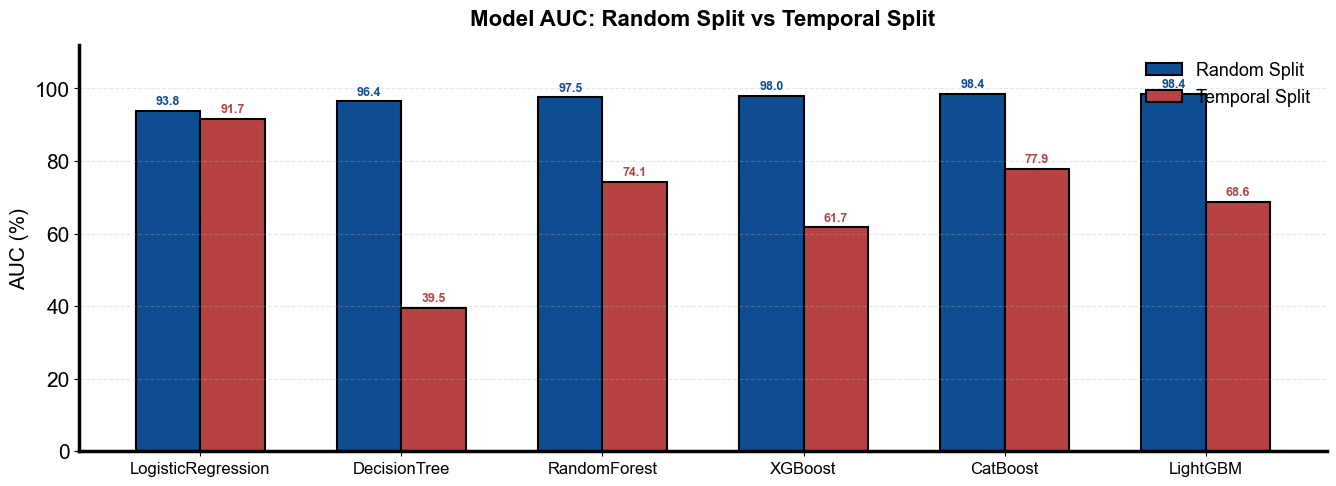

Figure saved to: C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\models\split_comparison_auc.png


In [7]:
# ── AUC comparison bar chart ──
fig, ax = plt.subplots(figsize=(14, 5.5))
x = np.arange(len(models)); w = 0.32
r_aucs = df_rand['auc_pct'].values
t_aucs = df_time['auc_pct'].values

bars_r = ax.bar(x - w/2, r_aucs, w, label='Random Split',
                color=PALETTE['blue_main'], edgecolor='black', linewidth=1.5)
bars_t = ax.bar(x + w/2, t_aucs, w, label='Temporal Split',
                color=PALETTE['red_strong'], edgecolor='black', linewidth=1.5)

for bar, val in zip(bars_r, r_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=PALETTE['blue_main'])
for bar, val in zip(bars_t, t_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=PALETTE['red_strong'])

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('AUC (%)', fontsize=15)
ax.set_title('Model AUC: Random Split vs Temporal Split', fontsize=16, fontweight='bold', pad=14)
ax.legend(fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_ylim(0, 112)

fig.tight_layout(pad=2)
fig.savefig(FIGURES_MODELS / 'split_comparison_auc.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_MODELS / 'split_comparison_auc.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to:", FIGURES_MODELS / "split_comparison_auc.png")

In [8]:
print(f"Best random: {df_rand.loc[df_rand['auc'].idxmax(), 'model']}  AUC={df_rand['auc'].max()*100:.2f}%")
print(f"Best temporal: {df_time.loc[df_time['auc'].idxmax(), 'model']}  AUC={df_time['auc'].max()*100:.2f}%")

Best random: CatBoost  AUC=98.40%
Best temporal: LogisticRegression  AUC=91.65%


,train_ratio,test_ratio,train_delay_rate,test_delay_rate,SPW,AUC,F1
0,70%,30%,72.67%,41.08%,0.38,0.8074,0.5839
1,75%,25%,71.98%,36.81%,0.39,0.7942,0.5344
2,80%,20%,72.37%,26.48%,0.38,0.8349,0.7037
3,85%,15%,71.02%,18.85%,0.41,0.9233,0.6667


AUC mean: 0.8399  std: 0.0503  range: 0.1291
[ALERT] AUC variation > 2pp — cutoff highly sensitive, must switch to TimeSeriesSplit.


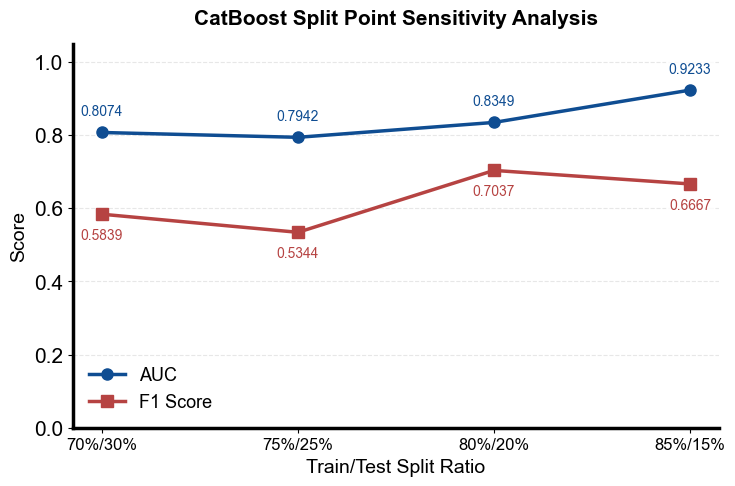

[OK] Sensitivity plot → C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\models\split_sensitivity.png


In [9]:
# ── CatBoost split sensitivity analysis (reusing df_sorted) ──
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, f1_score
from logistics_delay.features.engineering import FEATURES_XGB, XGB_CAT_COLS
from logistics_delay.utils.paths import SEED

CB_PARAMS = {
    "learning_rate": 0.05, "depth": 8, "iterations": 100,
    "l2_leaf_reg": 5, "border_count": 64,
    "bagging_temperature": 1, "random_strength": 0,
}

feature_list = FEATURES_XGB
cat_feats = [c for c in XGB_CAT_COLS if c in feature_list]
split_ratios = [0.70, 0.75, 0.80, 0.85]

records = []
for ratio in split_ratios:
    split_idx = int(len(df_sorted) * ratio)
    X_tr = df_sorted.loc[:split_idx - 1, feature_list].reset_index(drop=True)
    X_te = df_sorted.loc[split_idx:, feature_list].reset_index(drop=True)
    y_tr = df_sorted.loc[:split_idx - 1, "Answer"].reset_index(drop=True)
    y_te = df_sorted.loc[split_idx:, "Answer"].reset_index(drop=True)
    spw = len(y_tr[y_tr == 0]) / max(len(y_tr[y_tr == 1]), 1)

    model = CatBoostClassifier(**CB_PARAMS, class_weights={0: 1.0, 1: spw},
                                random_seed=SEED, verbose=0, cat_features=cat_feats)
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = model.predict(X_te)

    records.append({
        "train_ratio": f"{int(ratio*100)}%",
        "test_ratio": f"{round((1-ratio)*100)}%",
        "train_delay_rate": f"{y_tr.mean()*100:.2f}%",
        "test_delay_rate": f"{y_te.mean()*100:.2f}%",
        "SPW": round(spw, 2),
        "AUC": round(roc_auc_score(y_te, y_prob), 4),
        "F1": round(f1_score(y_te, y_pred), 4),
    })

df_sens = pd.DataFrame(records)

# ── Print results table ──
display(df_sens)

auc_vals = df_sens["AUC"].astype(float).values
print(f"AUC mean: {auc_vals.mean():.4f}  std: {auc_vals.std():.4f}  range: {auc_vals.max() - auc_vals.min():.4f}")
if auc_vals.max() - auc_vals.min() < 0.01:
    print("[OK] AUC variation < 1pp — stable, single split acceptable.")
elif auc_vals.max() - auc_vals.min() < 0.02:
    print("[WARN] AUC variation 1~2pp — some sensitivity, consider using TimeSeriesSplit.")
else:
    print("[ALERT] AUC variation > 2pp — cutoff highly sensitive, must switch to TimeSeriesSplit.")

# ── Line chart: AUC & F1 ──
fig, ax1 = plt.subplots(figsize=(8, 5.5))

x = np.arange(len(split_ratios))
labels = [f"{int(r*100)}%/{round((1-r)*100)}%" for r in split_ratios]

ax1.plot(x, df_sens["AUC"].astype(float), "o-", color=PALETTE["blue_main"],
         linewidth=2.5, markersize=8, label="AUC")
ax1.plot(x, df_sens["F1"].astype(float), "s-", color=PALETTE["red_strong"],
         linewidth=2.5, markersize=8, label="F1 Score")

for i in range(len(split_ratios)):
    ax1.annotate(f"{df_sens['AUC'].values[i]}",
                 (x[i], float(df_sens['AUC'].values[i])),
                 textcoords="offset points", xytext=(0, 12),
                 ha="center", fontsize=10, color=PALETTE["blue_main"],
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8))
    ax1.annotate(f"{df_sens['F1'].values[i]}",
                 (x[i], float(df_sens['F1'].values[i])),
                 textcoords="offset points", xytext=(0, -18),
                 ha="center", fontsize=10, color=PALETTE["red_strong"],
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8))

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=12)
ax1.set_xlabel("Train/Test Split Ratio", fontsize=14)
ax1.set_ylabel("Score", fontsize=14)
ax1.set_title("CatBoost Split Point Sensitivity Analysis", fontsize=15, fontweight="bold", pad=14)
ax1.legend(fontsize=13, loc="lower left")
ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.set_ylim(0, 1.05)

fig.tight_layout(pad=2)
fig.savefig(FIGURES_MODELS / "split_sensitivity.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES_MODELS / "split_sensitivity.pdf", dpi=300, bbox_inches="tight")
plt.show()
print(f"[OK] Sensitivity plot → {FIGURES_MODELS / 'split_sensitivity.png'}")